In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

## 1. Load Dataset

The Wine Quality dataset is loaded using pandas. It contains physicochemical properties of wine along with a quality score ranging from 3 to 8.

In [2]:
df = pd.read_csv("WineQT.csv")

df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [3]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Number of rows: 1143
Number of columns: 13

Column names:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality', 'Id']

Data types:
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
Id                        int64
dtype: object


## 2. Data Quality Check

Before building the models, the dataset is checked for missing values and duplicate records.

In [4]:
print("Missing values:")
print(df.isnull().sum())

print("\nTotal missing values:")
print(df.isnull().sum().sum())

Missing values:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

Total missing values:
0


In [5]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [6]:
df = df.drop_duplicates().copy()

In [7]:
quality_counts = df["quality"].value_counts().sort_index()

print(quality_counts)

quality
3      6
4     33
5    483
6    462
7    143
8     16
Name: count, dtype: int64


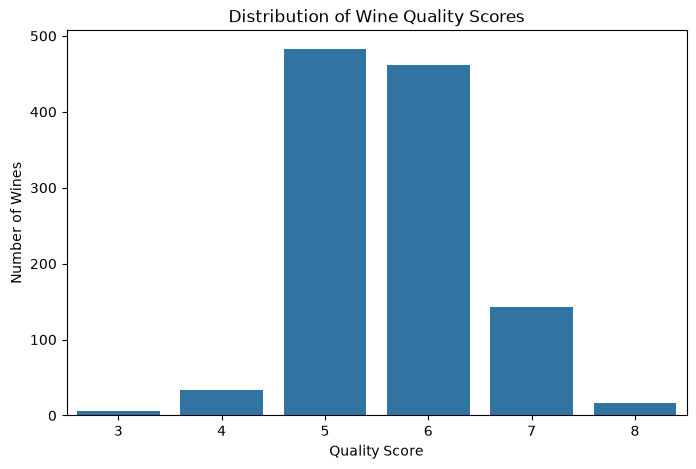

In [8]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="quality",
    order=sorted(df["quality"].unique())
)

plt.title("Distribution of Wine Quality Scores")
plt.xlabel("Quality Score")
plt.ylabel("Number of Wines")

plt.show()

### Observation

The quality scores are not evenly distributed. Quality scores 5 and 6 represent the majority of the observations, while quality scores 3 and 8 contain very few wines.

This class imbalance can affect classification because machine learning models may learn the majority classes more effectively than the underrepresented classes.

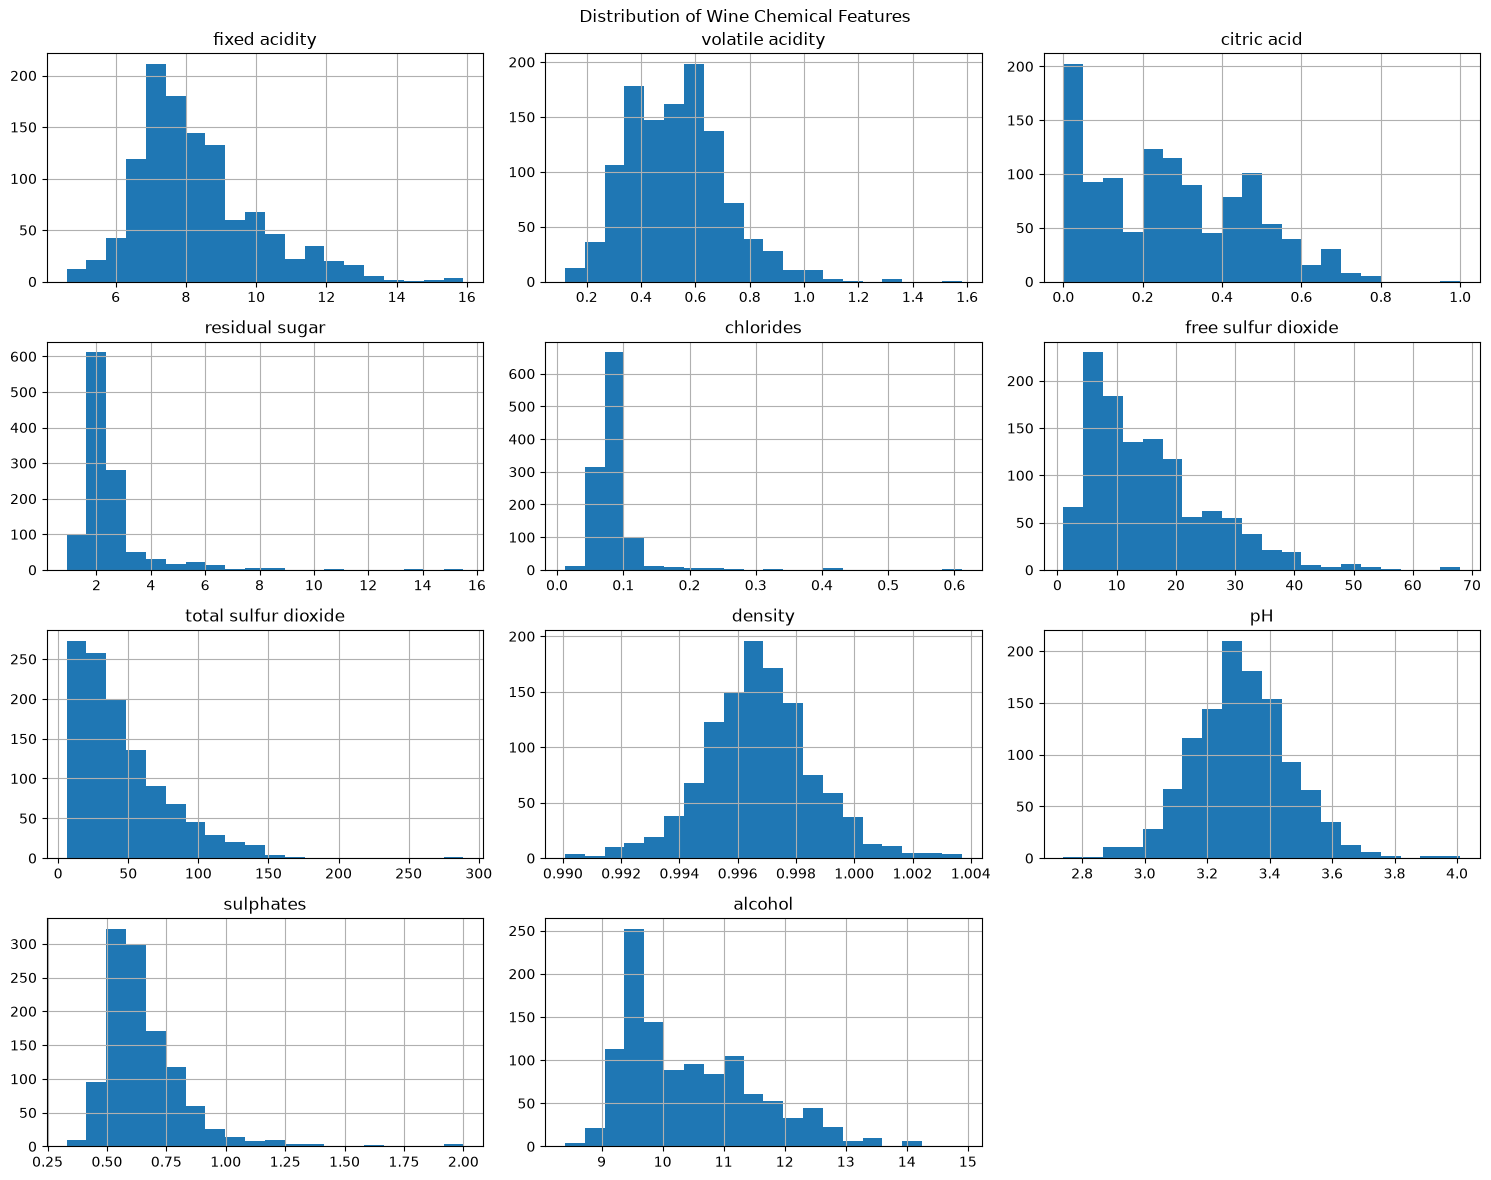

In [9]:
chemical_features = [
    "fixed acidity",
    "volatile acidity",
    "citric acid",
    "residual sugar",
    "chlorides",
    "free sulfur dioxide",
    "total sulfur dioxide",
    "density",
    "pH",
    "sulphates",
    "alcohol"
]

df[chemical_features].hist(
    figsize=(15, 12),
    bins=20
)

plt.suptitle("Distribution of Wine Chemical Features")

plt.tight_layout()
plt.show()

### Observation

The chemical features show different distributions and scales. Some variables such as residual sugar and sulfur dioxide are right-skewed, while variables such as pH and density have narrower ranges.

Because the models use features with different scales, scaling will be particularly important for SGD and SVC.

## 3. Correlation Analysis

A correlation matrix is used to examine the linear relationships between the physicochemical properties and wine quality.

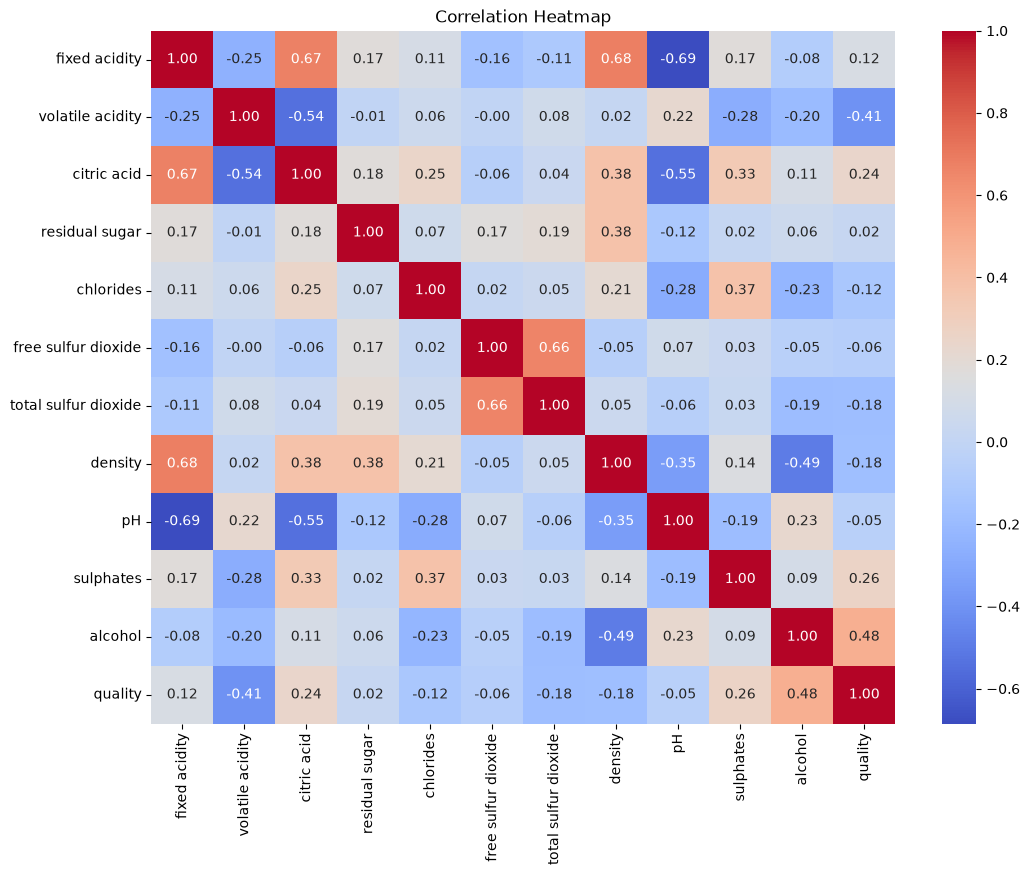

In [10]:
plt.figure(figsize=(12, 9))

correlation_matrix = df[chemical_features + ["quality"]].corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

## 4. Feature Engineering — Quality Groups

The original wine quality score ranges from 3 to 8. To simplify the classification problem and reduce the effect of highly underrepresented individual quality scores, the scores are grouped into three categories:

- Low: quality 3–4
- Medium: quality 5–6
- High: quality 7–8

This creates a three-class classification problem that is easier to interpret while retaining the distinction between lower, average, and higher quality wines.

In [11]:
def quality_group(quality):
    if quality <= 4:
        return "Low"
    elif quality <= 6:
        return "Medium"
    else:
        return "High"

df["quality_group"] = df["quality"].apply(quality_group)

df[["quality", "quality_group"]].head(10)

,quality,quality_group
0,5,Medium
1,5,Medium
2,5,Medium
3,6,Medium
4,5,Medium
5,5,Medium
6,5,Medium
7,7,High
8,7,High
9,5,Medium


In [12]:
group_counts = df["quality_group"].value_counts()

print(group_counts)

quality_group
Medium    945
High      159
Low        39
Name: count, dtype: int64


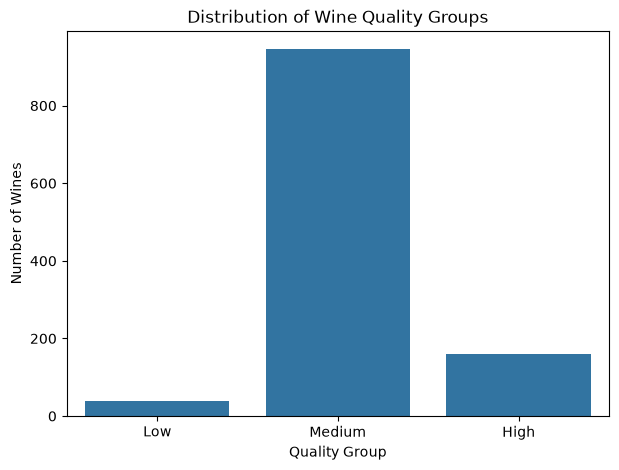

In [13]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="quality_group",
    order=["Low", "Medium", "High"]
)

plt.title("Distribution of Wine Quality Groups")
plt.xlabel("Quality Group")
plt.ylabel("Number of Wines")

plt.show()

### Observation

After grouping the quality scores, the dataset contains three classes: Low, Medium, and High.

The Medium class remains the largest class, while Low and High are smaller. Therefore, some class imbalance remains and should be considered when interpreting model performance.

In [14]:
X = df[chemical_features]

y = df["quality_group"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (1143, 11)
Target shape: (1143,)


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 914
Testing samples: 229


### Why Stratification?

Stratification is used during the train/test split to preserve approximately the same proportion of Low, Medium, and High quality wines in both the training and testing datasets.

This is especially important because the classes are not perfectly balanced.

## 5. Model 1 — Random Forest

Random Forest is an ensemble classification algorithm that combines multiple decision trees. It can capture nonlinear relationships between physicochemical properties and wine quality.

In [16]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [17]:
rf_accuracy = accuracy_score(
    y_test,
    rf_predictions
)

print("Random Forest Accuracy:", rf_accuracy)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        rf_predictions,
        zero_division=0
    )
)

Random Forest Accuracy: 0.8602620087336245

Classification Report:
              precision    recall  f1-score   support

        High       0.67      0.56      0.61        32
         Low       0.00      0.00      0.00         8
      Medium       0.89      0.95      0.92       189

    accuracy                           0.86       229
   macro avg       0.52      0.50      0.51       229
weighted avg       0.83      0.86      0.84       229



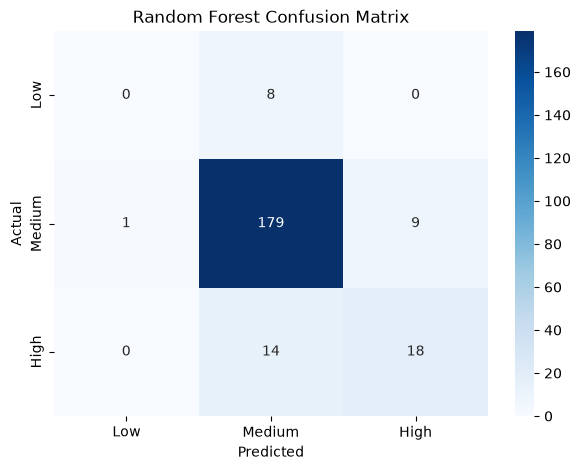

In [18]:
labels = ["Low", "Medium", "High"]

rf_cm = confusion_matrix(
    y_test,
    rf_predictions,
    labels=labels
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [19]:
feature_importance = pd.DataFrame({
    "Feature": chemical_features,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
10,alcohol,0.155432
1,volatile acidity,0.121587
9,sulphates,0.104312
2,citric acid,0.092809
7,density,0.088104
4,chlorides,0.087150
0,fixed acidity,0.080798
6,total sulfur dioxide,0.073440
3,residual sugar,0.073439
8,pH,0.065370


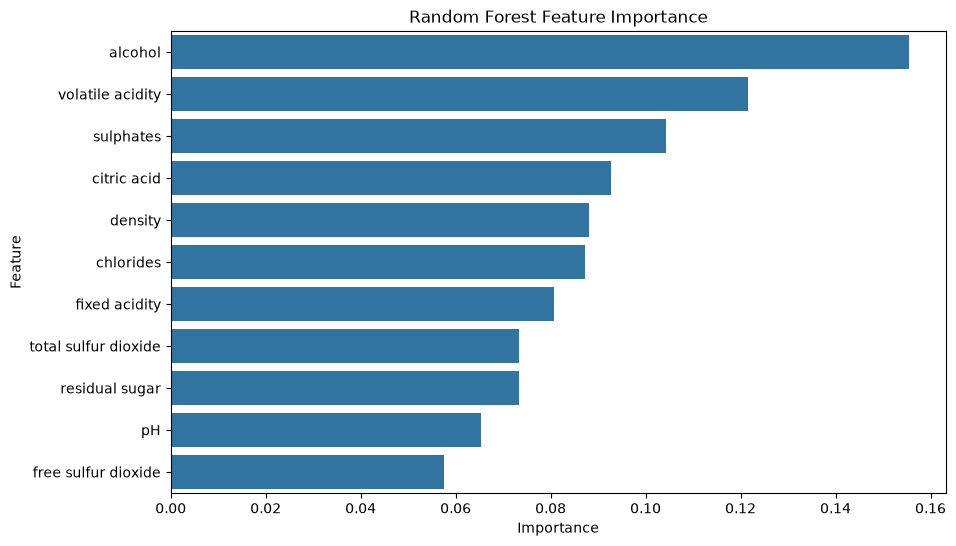

In [20]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

### Observation

The feature-importance chart shows the relative contribution of each physicochemical property to the Random Forest's predictions.

The most important features are identified from the model's calculated feature importance values. These values indicate how useful the features were for the Random Forest splits; they do not establish that a feature causes wine quality to change.

In [21]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

## 6. Model 2 — Stochastic Gradient Descent

The SGD classifier uses stochastic gradient descent to learn a linear classification model.

Because the chemical features have different numerical scales, standardisation is applied before training the SGD model.

In [22]:
sgd_model = Pipeline([
    ("scaler", StandardScaler()),
    (
        "classifier",
        SGDClassifier(
            random_state=42,
            max_iter=1000,
            tol=1e-3
        )
    )
])

sgd_model.fit(X_train, y_train)

sgd_predictions = sgd_model.predict(X_test)

print("SGD model trained successfully.")

SGD model trained successfully.


In [23]:
sgd_accuracy = accuracy_score(
    y_test,
    sgd_predictions
)

print("SGD Accuracy:", sgd_accuracy)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        sgd_predictions,
        zero_division=0
    )
)

SGD Accuracy: 0.8209606986899564

Classification Report:
              precision    recall  f1-score   support

        High       0.48      0.44      0.46        32
         Low       0.00      0.00      0.00         8
      Medium       0.87      0.92      0.89       189

    accuracy                           0.82       229
   macro avg       0.45      0.45      0.45       229
weighted avg       0.79      0.82      0.80       229



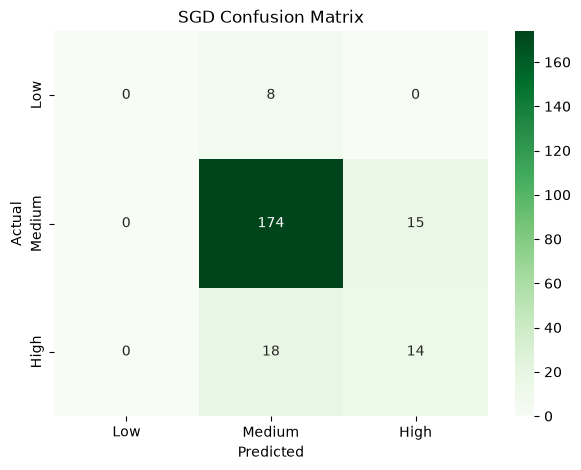

In [24]:
sgd_cm = confusion_matrix(
    y_test,
    sgd_predictions,
    labels=labels
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    sgd_cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=labels,
    yticklabels=labels
)

plt.title("SGD Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## 7. Model 3 — Support Vector Classifier

Support Vector Classifier (SVC) attempts to find decision boundaries that separate the different wine quality groups.

Standardisation is applied because SVC is sensitive to the scale of the input features.

In [25]:
svc_model = Pipeline([
    ("scaler", StandardScaler()),
    (
        "classifier",
        SVC(
            kernel="rbf",
            random_state=42
        )
    )
])

svc_model.fit(X_train, y_train)

svc_predictions = svc_model.predict(X_test)

print("SVC model trained successfully.")

SVC model trained successfully.


In [26]:
svc_accuracy = accuracy_score(
    y_test,
    svc_predictions
)

print("SVC Accuracy:", svc_accuracy)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        svc_predictions,
        zero_division=0
    )
)

SVC Accuracy: 0.8427947598253275

Classification Report:
              precision    recall  f1-score   support

        High       0.67      0.25      0.36        32
         Low       0.00      0.00      0.00         8
      Medium       0.85      0.98      0.91       189

    accuracy                           0.84       229
   macro avg       0.51      0.41      0.42       229
weighted avg       0.80      0.84      0.80       229



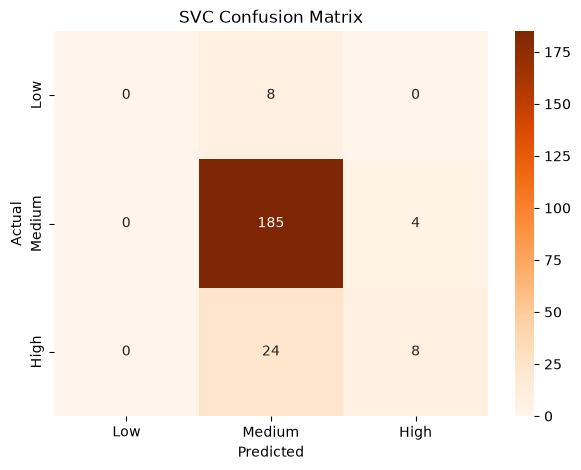

In [27]:
svc_cm = confusion_matrix(
    y_test,
    svc_predictions,
    labels=labels
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    svc_cm,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=labels,
    yticklabels=labels
)

plt.title("SVC Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [28]:

comparison = pd.DataFrame({
    "Model": [
        "Random Forest",
        "SGD",
        "SVC"
    ],
    "Accuracy": [
        rf_accuracy,
        sgd_accuracy,
        svc_accuracy
    ]
})

comparison

,Model,Accuracy
0,Random Forest,0.860262
1,SGD,0.820961
2,SVC,0.842795


In [29]:
from sklearn.metrics import precision_score, recall_score, f1_score

rf_precision = precision_score(
    y_test, rf_predictions,
    average="weighted",
    zero_division=0
)

rf_recall = recall_score(
    y_test, rf_predictions,
    average="weighted",
    zero_division=0
)

rf_f1 = f1_score(
    y_test, rf_predictions,
    average="weighted",
    zero_division=0
)

sgd_precision = precision_score(
    y_test, sgd_predictions,
    average="weighted",
    zero_division=0
)

sgd_recall = recall_score(
    y_test, sgd_predictions,
    average="weighted",
    zero_division=0
)

sgd_f1 = f1_score(
    y_test, sgd_predictions,
    average="weighted",
    zero_division=0
)

svc_precision = precision_score(
    y_test, svc_predictions,
    average="weighted",
    zero_division=0
)

svc_recall = recall_score(
    y_test, svc_predictions,
    average="weighted",
    zero_division=0
)

svc_f1 = f1_score(
    y_test, svc_predictions,
    average="weighted",
    zero_division=0
)

In [30]:
comparison = pd.DataFrame({
    "Model": [
        "Random Forest",
        "SGD",
        "SVC"
    ],
    "Accuracy": [
        rf_accuracy,
        sgd_accuracy,
        svc_accuracy
    ],
    "Precision": [
        rf_precision,
        sgd_precision,
        svc_precision
    ],
    "Recall": [
        rf_recall,
        sgd_recall,
        svc_recall
    ],
    "F1 Score": [
        rf_f1,
        sgd_f1,
        svc_f1
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.860262,0.828152,0.860262,0.842872
1,SGD,0.820961,0.785495,0.820961,0.802481
2,SVC,0.842795,0.796779,0.842795,0.802960


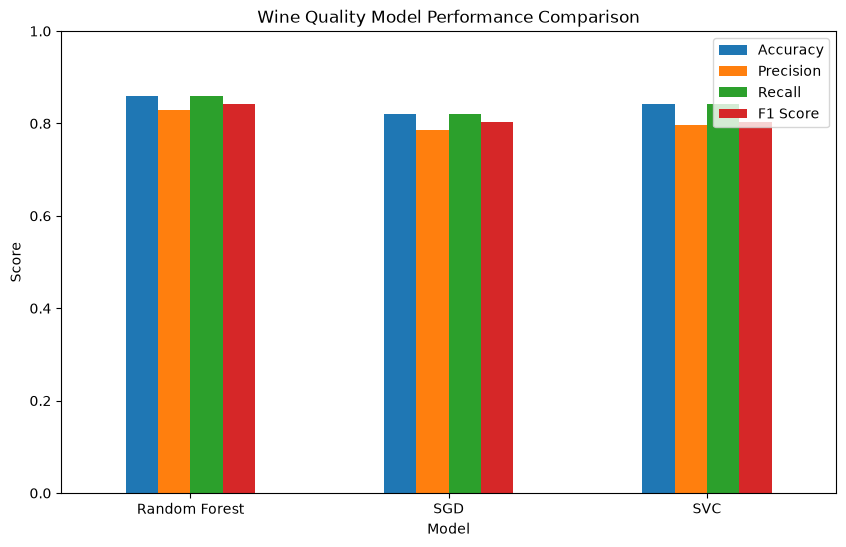

In [31]:
comparison.set_index("Model").plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Wine Quality Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)

plt.show()

## 8. Class Imbalance Discussion

The original quality scores were strongly imbalanced, with quality scores 5 and 6 representing most of the observations and scores 3 and 8 having very few examples.

Grouping the scores into Low, Medium, and High reduces the number of classes, but the resulting classes are still not perfectly balanced.

Class imbalance can cause a model to perform better on the majority class while performing less effectively on minority classes. Therefore, accuracy alone should not be used to assess the models. The classification reports, including precision, recall, and F1-score for each class, should also be examined.

# 9. Conclusion

This project developed a machine learning classification system for predicting wine quality groups from physicochemical properties.

The original quality scores were converted into three categories:

- Low: quality 3–4
- Medium: quality 5–6
- High: quality 7–8

Exploratory data analysis was performed using feature distribution plots and a correlation heatmap. The dataset showed class imbalance, particularly in the original quality scores.

Three classification models were trained:

1. Random Forest
2. Stochastic Gradient Descent
3. Support Vector Classifier

The models were evaluated using accuracy, precision, recall, F1-score, classification reports, and confusion matrices.

Random Forest feature importance was also examined to understand which physicochemical properties contributed most to its predictions.

The model comparison table provides the measured performance of all three classifiers. The model selected for potential deployment should be based on the evaluation results, with particular attention to F1-score and minority-class performance rather than accuracy alone.

### Possible Real-World Applications

A wine-quality classification system could assist with:

- Wine quality screening
- Quality-control processes
- Production monitoring
- Identifying wines requiring additional inspection
- Supporting winemaking and laboratory analysis

In [32]:
print("Dataset shape:", df.shape)

print("\nQuality groups:")
print(df["quality_group"].value_counts())

print("\nModel Comparison:")
print(comparison)

Dataset shape: (1143, 14)

Quality groups:
quality_group
Medium    945
High      159
Low        39
Name: count, dtype: int64

Model Comparison:
           Model  Accuracy  Precision    Recall  F1 Score
0  Random Forest  0.860262   0.828152  0.860262  0.842872
1            SGD  0.820961   0.785495  0.820961  0.802481
2            SVC  0.842795   0.796779  0.842795  0.802960
